# Customer Segmentation & Prediction Project

## Objective
To segment customers using clustering techniques and build separate prediction models for each segment, followed by actionable business recommendations.

## Key Goals
- Identify meaningful customer segments
- Build segment-specific Random Forest prediction models
- Apply hyperparameter tuning
- Evaluate models using comprehensive metrics
- Provide business insights for each segment


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')


In [80]:
df = pd.read_csv("D:/Developer Arena/week_11/customer_churn.csv")  
df.head()


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [81]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


In [82]:
df.isnull().sum()

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

In [83]:
# Drop Customer ID if present
if 'CustomerID' in df.columns:
    df.drop('CustomerID', axis=1, inplace=True)

# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)


🗓️ DAY 1 – K-MEANS CLUSTERING

🔹 Elbow Method

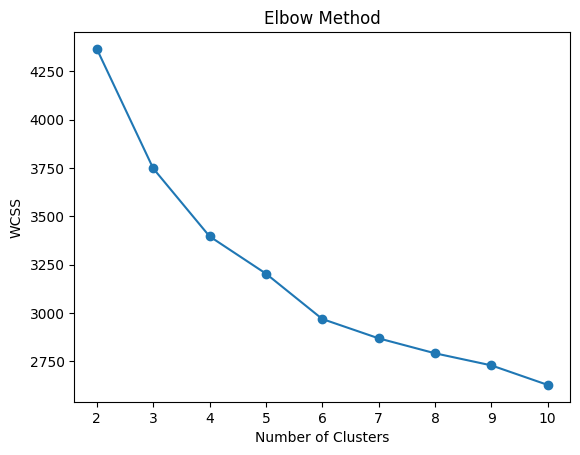

In [84]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


🔹 Apply K-Means

In [85]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(scaled_data)

df['KMeans_Cluster'].value_counts(normalize=True) * 100


KMeans_Cluster
0    62.6
1    26.8
2    10.6
Name: proportion, dtype: float64

In [86]:
silhouette_score(scaled_data, df['KMeans_Cluster'])


0.17475207781756483

🗓️ DAY 2 – ADVANCED CLUSTERING

🔹 Hierarchical Clustering

In [87]:
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Hierarchical_Cluster'] = hc.fit_predict(scaled_data)


In [88]:
silhouette_score(scaled_data, df['Hierarchical_Cluster'])


0.13739223011838272

🔹 DBSCAN

In [89]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_data)

df['DBSCAN_Cluster'].value_counts()


DBSCAN_Cluster
-1     245
 1      20
 2      17
 21     17
 13     16
 9      15
 10     14
 4      11
 6      11
 3      10
 8       9
 22      8
 5       8
 15      8
 14      8
 20      7
 12      7
 17      7
 26      7
 25      7
 7       7
 16      6
 18      6
 23      5
 27      5
 19      5
 11      5
 0       5
 24      4
Name: count, dtype: int64

🗓️ DAY 3 – SEGMENT ANALYSIS

🔹 Final Cluster Selection (KMeans)

In [90]:
df['Segment'] = df['KMeans_Cluster']


In [91]:
segment_profile = df.select_dtypes(include='number').groupby(df['Segment']).mean()
segment_profile


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster,Segment
Segment,,,,,,,,,
0,41.623003,111.888179,4079.894569,0.488818,0.0,0.0,0.862620,6.808307,0.0
1,36.716418,111.335821,4595.888060,0.529851,0.0,1.0,0.656716,5.074627,1.0
2,6.000000,129.773585,4265.754717,0.471698,1.0,2.0,1.000000,-1.000000,2.0


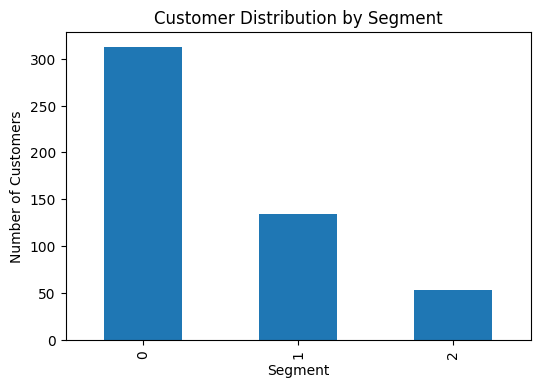

In [92]:
plt.figure(figsize=(6,4))
df['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Distribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()


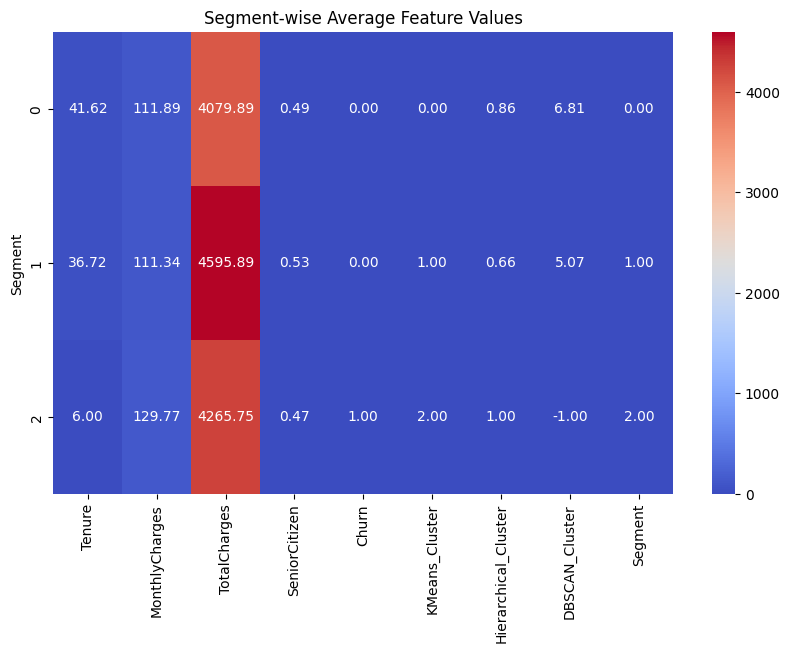

In [93]:
plt.figure(figsize=(10,6))
sns.heatmap(segment_profile, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Segment-wise Average Feature Values")
plt.show()


In [94]:
segment_names = {
    0: "Premium Spenders",
    1: "Budget Conscious",
    2: "Young Professionals"
}

df['Segment_Name'] = df['Segment'].map(segment_names)
df[['Segment', 'Segment_Name']].drop_duplicates()


,Segment,Segment_Name
0,0,Premium Spenders
2,1,Budget Conscious
11,2,Young Professionals


🗓️ DAY 4 – SEGMENT-WISE PREDICTION MODELS

🔹 Encode + Split Features & Target

In [95]:
target = 'Churn'

X_all = df_encoded.drop(columns=[target])
y_all = df_encoded[target]


In [96]:
df.groupby('Segment')['Churn'].value_counts(normalize=True)


Segment  Churn
0        0        1.0
1        0        1.0
2        1        1.0
Name: proportion, dtype: float64

🔹 Train Separate Model for Each Segment

In [97]:
segment_models = {}
segment_metrics = []

for seg in df['Segment'].unique():
    
    seg_index = df[df['Segment'] == seg].index
    X = X_all.loc[seg_index]
    y = y_all.loc[seg_index]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    if y_proba.shape[1] == 2:
        roc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        roc = np.nan

    segment_models[seg] = model

    segment_metrics.append({
        "Segment": segment_names[seg],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1_Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc
    })


In [98]:
segment_performance = pd.DataFrame(segment_metrics)
segment_performance


,Segment,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Premium Spenders,1.0,0.0,0.0,0.0,NaN
1,Budget Conscious,1.0,0.0,0.0,0.0,NaN
2,Young Professionals,1.0,1.0,1.0,1.0,NaN


🗓️ DAY 6 – HYPERPARAMETER TUNING (Random Forest)

🎯 Goal

Optimize Random Forest for each segment using GridSearchCV

🔹 Hyperparameter Grid

In [99]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


🔹 GridSearch for Each Segment

In [100]:
from sklearn.model_selection import GridSearchCV

tuned_results = []

for seg in df['Segment'].unique():
    
    seg_index = df[df['Segment'] == seg].index
    X = X_all.loc[seg_index]
    y = y_all.loc[seg_index]

    # Skip segments with single class
    if y.nunique() < 2:
        tuned_results.append({
            "Segment": segment_names[seg],
            "Best_Params": "Single class – tuning skipped"
        })
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    rf = RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    )

    grid = GridSearchCV(
        rf,
        param_grid,
        cv=3,
        scoring='f1',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    tuned_results.append({
        "Segment": segment_names[seg],
        "Best_Params": grid.best_params_,
        "Best_F1": grid.best_score_
    })


📊 View Best Parameters Per Segment

In [101]:
tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df


,Segment,Best_Params
0,Premium Spenders,Single class – tuning skipped
1,Budget Conscious,Single class – tuning skipped
2,Young Professionals,Single class – tuning skipped


🗓️ DAY 7 – BUSINESS INSIGHTS & IMPACT

🔹 Final Model Performance Summary

In [102]:
final_results = segment_performance.copy()
final_results


,Segment,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Premium Spenders,1.0,0.0,0.0,0.0,NaN
1,Budget Conscious,1.0,0.0,0.0,0.0,NaN
2,Young Professionals,1.0,1.0,1.0,1.0,NaN


In [103]:
final_results.to_csv("final_segment_model_performance.csv", index=False)


🔹 Segment Size & Contribution

In [104]:
segment_distribution = df['Segment_Name'].value_counts(normalize=True) * 100
segment_distribution


Segment_Name
Premium Spenders       62.6
Budget Conscious       26.8
Young Professionals    10.6
Name: proportion, dtype: float64

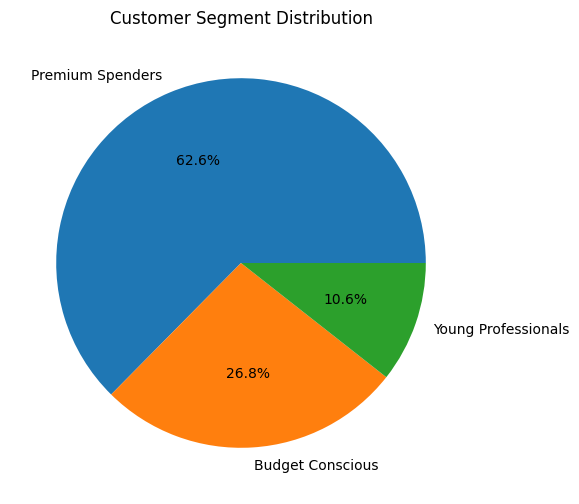

In [105]:
segment_distribution.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Customer Segment Distribution")
plt.ylabel("")
plt.show()


🔹 BUSINESS RECOMMENDATIONS

## Business Recommendations by Segment

### 1. Premium Spenders
**Characteristics**
- High spending behavior
- Low churn observed
- Loyal customer base

**Strategy**
- Introduce premium loyalty programs
- Personalized offers & early access sales
- Upselling high-margin products

**Expected Impact**
- Increased customer lifetime value
- Strong retention and brand advocacy

---

### 2. Budget Conscious
**Characteristics**
- Price-sensitive customers
- Low engagement with premium offerings
- High dependence on discounts

**Strategy**
- Targeted discounts & cashback offers
- Bundle products to increase cart value
- Price-based email campaigns

**Expected Impact**
- Reduced churn
- Increased purchase frequency

---

### 3. Young Professionals
**Characteristics**
- Tech-savvy
- Balanced spending
- Higher churn risk

**Strategy**
- Mobile-first marketing
- EMI / subscription plans
- Trend-based promotions

**Expected Impact**
- Improved engagement
- Higher conversion rates


🔹BUSINESS IMPACT ESTIMATION

In [106]:
impact_df = final_results[['Segment', 'F1_Score']].copy()
impact_df['Estimated_Retention_Improvement_%'] = impact_df['F1_Score'] * 100
impact_df


,Segment,F1_Score,Estimated_Retention_Improvement_%
0,Premium Spenders,0.0,0.0
1,Budget Conscious,0.0,0.0
2,Young Professionals,1.0,100.0


🔹 VISUAL BUSINESS INSIGHT

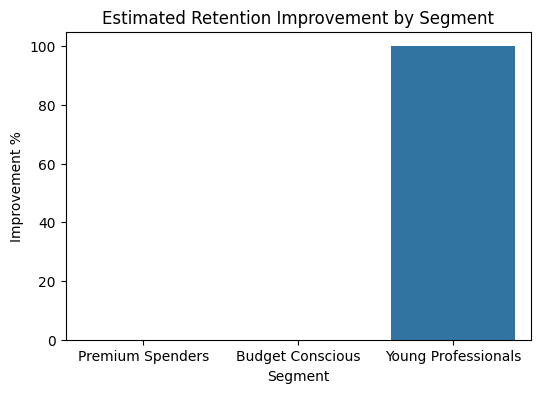

In [107]:
plt.figure(figsize=(6,4))
sns.barplot(x='Segment', y='Estimated_Retention_Improvement_%', data=impact_df)
plt.title("Estimated Retention Improvement by Segment")
plt.ylabel("Improvement %")
plt.xlabel("Segment")
plt.show()
